In [145]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from tqdm import tqdm
import copy
plt.style.use("default")

In [146]:
import torch

In [147]:
X, y = fetch_california_housing(return_X_y=True)

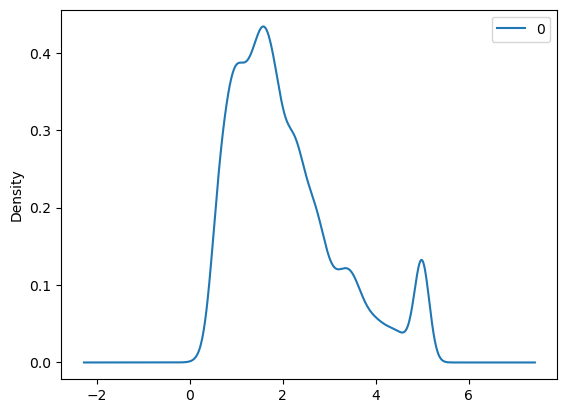

In [148]:
pd.DataFrame(y).plot.kde()
plt.show()

In [199]:
class GammaRegression(torch.nn.Module):

    def __init__(self, input_dim, lr=1e-3, batch_size=32, device=None, bias=True):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.batch_size = batch_size
        self.lr = lr
        self.linear = torch.nn.Linear(input_dim, 1, bias=bias)
        self.loss_history = []
        self.val_loss_history = []

        self.to(self.device)

    def forward(self, x):

        x = x.to(self.device)

        return self.linear(x)

    def predict(self, X):

        return torch.exp(self.forward(X))

    def loss(self, y_pred, y):

        return torch.mean(torch.abs(y_pred-y))

    def fit(self, X, y, X_val=None, y_val=None, epochs=50, patience=5, tol=1e-4):
        
        X = X.to(self.device)
        y = y.to(self.device)

        if X_val is not None and y_val is not None:
            X_val = X_val.to(self.device)
            y_val = y_val.to(self.device)

        dataset = torch.utils.data.TensorDataset(X, y)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        optimizer = torch.optim.SGD(self.parameters(), lr=self.lr)

        best_loss = float("inf")
        best_state = None
        patience_counter = 0

        pbar = tqdm(range(epochs), desc="Training", leave=True)

        for epoch in pbar:

            self.train()
            epoch_loss = 0.0

            for xb, yb in loader:

                optimizer.zero_grad()

                y_pred = self.forward(xb)

                loss = self.loss(y_pred, yb)

                loss.backward()

                optimizer.step()

                epoch_loss += loss.item()

            epoch_loss = epoch_loss / len(loader)

            self.loss_history.append(epoch_loss)

            if X_val is not None and y_val is not None:

                self.eval()

                with torch.no_grad():

                    y_val_pred = self.forward(X_val)
                    val_loss = self.loss(y_val_pred, y_val).item()

                self.val_loss_history.append(val_loss)

                if val_loss < best_loss - tol:

                    best_loss = val_loss
                    best_state = copy.deepcopy(self.state_dict())
                    patience_counter = 0

                else:

                    patience_counter = patience_counter + 1

                if val_loss is not None:

                   pbar.set_postfix({
                       "train_loss": f"{epoch_loss:.4f}",
                        "val_loss": f"{val_loss:.4f}"
                            })

                else:

                    pbar.set_postfix({
                       "train_loss": f"{epoch_loss:.4f}"
                            })

                if patience_counter >= patience:
                    pbar.set_postfix({"early_stopping": epoch})
                    break

        if best_state is not None:
            self.load_state_dict(best_state)

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
pca = PCA().fit(X_train)

pca.explained_variance_ratio_.cumsum()

array([0.51887197, 0.87361684, 0.97443678, 0.99147079, 0.99688458,
       0.99944062, 0.99989871, 1.        ])

In [201]:
X_train = pca.transform(X_train)
X_test = pca.transform(X_test)

In [202]:
X_train, X_test = torch.Tensor(X_train), torch.Tensor(X_test)
y_train, y_test = torch.Tensor(y_train), torch.Tensor(y_test)

In [203]:
p = X_train.shape[1]
gamma_model = GammaRegression(p, lr=1e-3)

In [204]:
gamma_model.fit(X_train, y_train, X_test, y_test, epochs=500, tol=1e-10)

Training:  16%|████████                                            | 78/500 [00:50<04:31,  1.55it/s, early_stopping=78]


In [209]:
gamma_model.forward(X_test)[:20]

tensor([[1.7895],
        [1.7991],
        [1.8151],
        [1.8069],
        [1.8602],
        [1.7921],
        [1.7704],
        [1.8064],
        [1.8064],
        [1.7732],
        [1.8089],
        [1.7993],
        [1.7625],
        [1.8162],
        [1.7861],
        [1.8043],
        [1.8352],
        [1.8018],
        [1.8052],
        [1.7793]], device='cuda:0', grad_fn=<SliceBackward0>)

In [206]:
y_train

tensor([1.8670, 1.4440, 1.2700,  ..., 1.8440, 0.8330, 1.3400])

In [211]:
y_test[:20]

tensor([1.4220, 1.8960, 1.8160, 1.7800, 5.0000, 1.3970, 0.6060, 3.5630, 2.1190,
        1.1790, 3.0410, 2.2500, 0.6760, 0.8320, 1.9250, 2.2150, 4.4330, 2.6730,
        2.4790, 2.2070])

In [ ]:
gamma_model.